In [2]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from tqdm import tqdm
import joblib
from pathlib import Path

In [3]:
year = 2021
RAW_XY_FOLDERPATH = Path(f'../data/silver/Xy-{year}')

# Load data

In [4]:
raw_Xy = pd.read_parquet(RAW_XY_FOLDERPATH / "Xy.parquet")
metadata_df = pd.read_parquet(RAW_XY_FOLDERPATH / "metadata_df.parquet")

raw_Xy.head(1)

,red,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,red_11x11_median,...,ndwi_11x11_var,tci_11x11_median,ndvi_11x11_median,evi_11x11_median,evi2_11x11_median,ndre_b5_11x11_median,ndre_b6_11x11_median,ndre_b7_11x11_median,gndvi_11x11_median,ndwi_11x11_median
1,0.121569,0.121569,0.109804,0.129412,0.007843,0.117647,0.109804,0.129412,0.007843,0.117647,...,-0.230769,0.036183,0.25,0.083682,-0.099099,0.106383,0.050505,0.019608,0.132626,-0.099099


# Build Xy

In [8]:
def get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl', 'region']
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    features += ['valid_observations']
    features += ['cloud_confidence']
    features += [e for e in X.columns if any(k in e for k in ['3x3', '5x5', '11x11'])]
    return X[features + ['y']]

Xy = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(raw_Xy)
Xy.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,tci_11x11_median,ndvi_11x11_median,evi_11x11_median,evi2_11x11_median,ndre_b5_11x11_median,ndre_b6_11x11_median,ndre_b7_11x11_median,gndvi_11x11_median,ndwi_11x11_median,y
1,0.058824,0.086275,0.121569,0.160784,0.180392,0.196078,0.196078,0.203922,0.239216,0.180392,...,0.036183,0.25,0.083682,-0.099099,0.106383,0.050505,0.019608,0.132626,-0.099099,False


# Prep hyperparam optimization

In [9]:
import numpy as np
import optuna
import lightgbm as lgb
from sklearn.model_selection import cross_validate, GroupKFold

def optuna_objective_factory(X, y, groups, always_train_mask, n_splits):
    """
    always_train_mask: A boolean list/array of the same length as X. 
                       True means the sample is always used in training.
                       False means the sample is rotated via GroupKFold.
    """
    
    # --- 1. Pre-calculate the custom CV splits once ---
    always_train_mask = np.array(always_train_mask)
    
    # Get absolute indices for both groups
    fixed_indices = np.where(always_train_mask)[0]
    rot_indices = np.where(~always_train_mask)[0]
    
    # Extract just the groups for the rotating portion
    groups_rot = np.array(groups)[rot_indices]
    
    # GroupKFold only needs the shape and the groups, so we can use a dummy array
    dummy_X_rot = np.zeros(len(rot_indices))
    
    gkf = GroupKFold(n_splits=n_splits)
    custom_cv = []
    
    # Generate the splits only on the rotating data
    for train_idx_rel, val_idx_rel in gkf.split(dummy_X_rot, dummy_X_rot, groups_rot):
        
        # Map the relative fold indices back to the absolute indices of the full dataset
        train_idx_rot = rot_indices[train_idx_rel]
        val_idx_rot = rot_indices[val_idx_rel]
        
        # Combine the fixed indices with the rotating training fold
        full_train_idx = np.concatenate([fixed_indices, train_idx_rot])
        
        # Append the (train, validation) tuple scikit-learn expects
        custom_cv.append((full_train_idx, val_idx_rot))

    # Pre-calculate the validation sizes for each fold
    val_sizes = [len(val_idx) for _, val_idx in custom_cv]

    # --- 2. The Objective Function ---
    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 15),
            'num_leaves': trial.suggest_int('num_leaves', 10, 256),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'n_jobs': -1,
            'verbose': -1,
            'random_state': 42
        }
        
        model = lgb.LGBMClassifier(**param)
        
        # Pass the pre-computed custom_cv list to the cv parameter
        scores = cross_validate(model, X, y, cv=custom_cv, scoring=['f1', 'precision', 'recall'], n_jobs=1, )
        
        trial.set_user_attr('f1s', scores["test_f1"])
        trial.set_user_attr('precisions', scores["test_precision"])
        trial.set_user_attr('recalls', scores["test_recall"])
        
        # Add the validation set sizes to the trial attributes
        trial.set_user_attr('val_sizes', val_sizes)
        
        return np.median(scores['test_f1'])

    return objective

# Train:test split

In [13]:
def train_test_split(Xy, metadata_df, region: str, test_size=0.2):
    """Split a train/test set, where all test samples are located within a region."""
    region_mask = Xy.region.apply(lambda x: x.lower()) == region

    if not region_mask.sum():
        raise ValueError(f'Region {region} not found.')

    # Discard not-in-region data
    Xy = Xy[region_mask]
    metadata_df = metadata_df[region_mask]
    print(f"Discarding out-of-region points: Kept {region_mask.sum()}/{len(region_mask)} ({region_mask.sum()/len(region_mask) * 100:.2f}%)")
    Xy = Xy.drop(columns=['region'])
    # Figure out which folds are for train/val and which for test
    region_fold_idxs = metadata_df.fold_idx[region_mask].unique()
    n_test_folds = int(np.floor(test_size * len(region_fold_idxs)))
    test_fold_idxs = np.random.choice(region_fold_idxs, size=n_test_folds, replace=False)
    test_mask = metadata_df.fold_idx.isin(test_fold_idxs)
    print(f"{len(test_fold_idxs)}/{len(region_fold_idxs)} regions for testing ({test_mask.sum()} points)")
    
    return Xy[~test_mask], metadata_df[~test_mask], Xy[test_mask], metadata_df[test_mask]

Xy_train, train_metadata_df, Xy_test, test_metadata_df = train_test_split(Xy, metadata_df, 'upper east', 0.2)
Xy_train.head(1)

Discarding out-of-region points: Kept 34820/915540 (3.80%)
20/100 regions for testing (7063 points)


,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,tci_11x11_median,ndvi_11x11_median,evi_11x11_median,evi2_11x11_median,ndre_b5_11x11_median,ndre_b6_11x11_median,ndre_b7_11x11_median,gndvi_11x11_median,ndwi_11x11_median,y
1,0.058824,0.086275,0.121569,0.160784,0.180392,0.196078,0.196078,0.203922,0.239216,0.180392,...,0.036183,0.25,0.083682,-0.099099,0.106383,0.050505,0.019608,0.132626,-0.099099,False


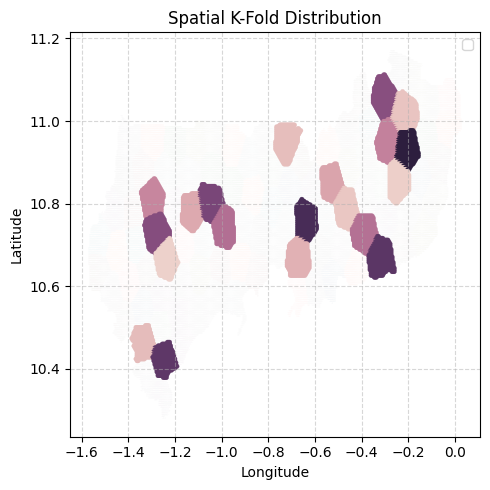

In [14]:
# Plot the folds
plt.figure(figsize=(5, 5))
sns.scatterplot(data=train_metadata_df, x='lon', y='lat', hue='fold_idx', palette='tab20', s=1, alpha=0.02, edgecolor=None)
sns.scatterplot(data=test_metadata_df, x='lon', y='lat', hue='fold_idx', color='r', s=10, alpha=1, edgecolor=None)

plt.title('Spatial K-Fold Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend([])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Train

In [15]:
import numpy as np
import optuna
import lightgbm as lgb
from scipy import stats
from sklearn.metrics import f1_score, precision_score, recall_score

def train_test_lgbm(X_train, y_train, X_test, y_test, groups, always_train_mask, n_splits=10, n_trials=3, n_clfs=5, ci_level=0.95):
    print("Starting Optuna hyperparameter optimization...")
    study = optuna.create_study(direction="maximize") 
    study.optimize(optuna_objective_factory(X_train, y_train, groups, always_train_mask, n_splits), n_trials=n_trials, show_progress_bar=True)
    
    # Store the best params (removing random_state if it's there, as we will override it)
    best_params = study.best_params.copy()
    if 'random_state' in best_params:
        del best_params['random_state']

    clfs = []
    yhats_train = []
    yhats_test = []
    
    # Dictionaries to store the metrics across the n runs
    metrics = {
        'train': {'f1': [], 'precision': [], 'recall': []},
        'test':  {'f1': [], 'precision': [], 'recall': []}
    }

    print(f"\nTraining {n_clfs} models with best hyperparameters and different random seeds...")
    
    for i in range(n_clfs):
        # Inject a unique random state for each iteration
        seed = 42 + i
        clf = lgb.LGBMClassifier(**best_params, random_state=seed)
        clf.fit(X_train, y_train)
        
        yhat_train = clf.predict(X_train)
        yhat_test = clf.predict(X_test)
        
        # Store models and predictions
        clfs.append(clf)
        yhats_train.append(yhat_train)
        yhats_test.append(yhat_test)
        
        # Calculate and store metrics for this specific seed
        metrics['train']['f1'].append(f1_score(y_train, yhat_train, zero_division=0))
        metrics['train']['precision'].append(precision_score(y_train, yhat_train, zero_division=0))
        metrics['train']['recall'].append(recall_score(y_train, yhat_train, zero_division=0))
        
        metrics['test']['f1'].append(f1_score(y_test, yhat_test, zero_division=0))
        metrics['test']['precision'].append(precision_score(y_test, yhat_test, zero_division=0))
        metrics['test']['recall'].append(recall_score(y_test, yhat_test, zero_division=0))

    # --- Helper to calculate and format Mean ± CI ---
    def calc_ci_string(data_array):
        mean_val = np.mean(data_array)
        if n_clfs < 2:
            return f"{mean_val:.4f}"
            
        se = stats.sem(data_array)
        # Degrees of freedom is n-1. Calculate the t-critical value.
        h = se * stats.t.ppf((1 + ci_level) / 2., n_clfs - 1)
        return f"{mean_val:.4f} ± {h:.4f}"

    print(f"\n--- OPTIMIZED MODEL EVALUATION ({n_clfs} Runs, {int(ci_level*100)}% CI) ---")
    print("TRAIN")
    print(f"- F1:        {calc_ci_string(metrics['train']['f1'])}")
    print(f"- Precision: {calc_ci_string(metrics['train']['precision'])}")
    print(f"- Recall:    {calc_ci_string(metrics['train']['recall'])}")
    
    print("\nTEST")
    print(f"- F1:        {calc_ci_string(metrics['test']['f1'])}")
    print(f"- Precision: {calc_ci_string(metrics['test']['precision'])}")
    print(f"- Recall:    {calc_ci_string(metrics['test']['recall'])}")

    # Return the lists of models, predictions (shape: [n_clfs, n_samples]), and optuna attrs
    return clfs, np.array(yhats_train), np.array(yhats_test), study.best_trial.user_attrs

In [20]:
def train_region(Xy, metadata_df, region, test_size=0.2, n_trials=100):
    
    # Get train:test
    Xy_train, train_metadata_df, Xy_test, test_metadata_df = train_test_split(Xy, metadata_df, region.lower(), test_size)    
    X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
    X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

    # Train
    outside_region_mask = np.full(len(Xy_train), False)
    clf, _, _, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, train_metadata_df.fold_idx, outside_region_mask, n_trials=n_trials);
    
    # Dump
    payload = {
        'X_train': X_train,
        'y_train': y_train,
        'metadata_df_train':  train_metadata_df,
        'X_test': X_test,
        'y_test': y_test,
        'metadata_df_test':  test_metadata_df,
        'clf': clf,
        "user_attrs": user_attrs,
    }
    
    joblib.dump(payload, f'trained-{region.lower()}-2021.joblib')

In [23]:
train_region(Xy, metadata_df, 'ashanti', 0.2, n_trials=1)

[I 2026-06-23 10:44:56,223] A new study created in memory with name: no-name-137ae387-d7de-4246-a7a3-34180a35210f


Discarding out-of-region points: Kept 95807/915540 (10.46%)
20/100 regions for testing (19112 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-23 10:45:34,771] Trial 0 finished with value: 0.7750762826273105 and parameters: {'n_estimators': 297, 'learning_rate': 0.04225084923059671, 'max_depth': 4, 'num_leaves': 236, 'subsample': 0.6332933876285055, 'colsample_bytree': 0.7241135071799971, 'min_child_samples': 78}. Best is trial 0 with value: 0.7750762826273105.

Training 5 models with best hyperparameters and different random seeds...

--- OPTIMIZED MODEL EVALUATION (5 Runs, 95% CI) ---
TRAIN
- F1:        0.8015 ± 0.0007
- Precision: 0.7920 ± 0.0011
- Recall:    0.8112 ± 0.0013

TEST
- F1:        0.7701 ± 0.0014
- Precision: 0.8094 ± 0.0004
- Recall:    0.7345 ± 0.0023


In [24]:
train_region(Xy, metadata_df, 'western north', 0.2, n_trials=1)

[I 2026-06-23 10:45:58,377] A new study created in memory with name: no-name-c38c479b-c729-40a0-8d3b-f1995d7388b4


Discarding out-of-region points: Kept 32268/915540 (3.52%)
20/100 regions for testing (6687 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-23 10:46:19,432] Trial 0 finished with value: 0.8347619787849851 and parameters: {'n_estimators': 471, 'learning_rate': 0.03712649575767528, 'max_depth': 4, 'num_leaves': 62, 'subsample': 0.7042376387409722, 'colsample_bytree': 0.6231815260781499, 'min_child_samples': 55}. Best is trial 0 with value: 0.8347619787849851.

Training 5 models with best hyperparameters and different random seeds...

--- OPTIMIZED MODEL EVALUATION (5 Runs, 95% CI) ---
TRAIN
- F1:        0.8740 ± 0.0006
- Precision: 0.8181 ± 0.0005
- Recall:    0.9382 ± 0.0009

TEST
- F1:        0.8463 ± 0.0015
- Precision: 0.8035 ± 0.0022
- Recall:    0.8939 ± 0.0017


In [25]:
train_region(Xy, metadata_df, 'western', 0.2, n_trials=1)

[I 2026-06-23 10:46:31,163] A new study created in memory with name: no-name-e2eb2d52-2f04-4e1e-9d5d-8da8fc3422d1


Discarding out-of-region points: Kept 37872/915540 (4.14%)
20/100 regions for testing (7521 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-23 10:47:37,187] Trial 0 finished with value: 0.7931389170658105 and parameters: {'n_estimators': 423, 'learning_rate': 0.09953283893751688, 'max_depth': 10, 'num_leaves': 101, 'subsample': 0.9264379105648485, 'colsample_bytree': 0.5957840385914333, 'min_child_samples': 99}. Best is trial 0 with value: 0.7931389170658105.

Training 5 models with best hyperparameters and different random seeds...

--- OPTIMIZED MODEL EVALUATION (5 Runs, 95% CI) ---
TRAIN
- F1:        0.9999 ± 0.0000
- Precision: 0.9998 ± 0.0000
- Recall:    1.0000 ± 0.0000

TEST
- F1:        0.8073 ± 0.0009
- Precision: 0.8087 ± 0.0026
- Recall:    0.8059 ± 0.0025


In [26]:
train_region(Xy, metadata_df, 'ahafo', 0.2, n_trials=1)

[I 2026-06-23 10:48:12,146] A new study created in memory with name: no-name-34a340f3-1439-4fe6-96eb-7605f48f5f1a


Discarding out-of-region points: Kept 20052/915540 (2.19%)
20/100 regions for testing (4004 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-23 10:48:25,296] Trial 0 finished with value: 0.8249573405403742 and parameters: {'n_estimators': 150, 'learning_rate': 0.12005466347667622, 'max_depth': 6, 'num_leaves': 78, 'subsample': 0.983931047957979, 'colsample_bytree': 0.9394901277022158, 'min_child_samples': 35}. Best is trial 0 with value: 0.8249573405403742.

Training 5 models with best hyperparameters and different random seeds...

--- OPTIMIZED MODEL EVALUATION (5 Runs, 95% CI) ---
TRAIN
- F1:        0.9635 ± 0.0030
- Precision: 0.9524 ± 0.0037
- Recall:    0.9748 ± 0.0026

TEST
- F1:        0.8446 ± 0.0031
- Precision: 0.8371 ± 0.0048
- Recall:    0.8523 ± 0.0046


In [27]:
train_region(Xy, metadata_df, 'central', 0.2, n_trials=1)

[I 2026-06-23 10:48:31,492] A new study created in memory with name: no-name-5328fcbe-c779-452f-be4b-17b1637167b6


Discarding out-of-region points: Kept 32385/915540 (3.54%)
20/100 regions for testing (6619 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-23 10:48:41,864] Trial 0 finished with value: 0.7781123975130033 and parameters: {'n_estimators': 117, 'learning_rate': 0.09228724192652543, 'max_depth': 12, 'num_leaves': 21, 'subsample': 0.7600037373814672, 'colsample_bytree': 0.7006806096377809, 'min_child_samples': 52}. Best is trial 0 with value: 0.7781123975130033.

Training 5 models with best hyperparameters and different random seeds...

--- OPTIMIZED MODEL EVALUATION (5 Runs, 95% CI) ---
TRAIN
- F1:        0.8369 ± 0.0005
- Precision: 0.8322 ± 0.0015
- Recall:    0.8416 ± 0.0015

TEST
- F1:        0.7586 ± 0.0020
- Precision: 0.7179 ± 0.0021
- Recall:    0.8042 ± 0.0045


# Use TCA
https://en.wikipedia.org/wiki/Tasseled_cap_transformation

# Use clustering min ?